In [1]:
import os
import sys
os.chdir("..")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df_listings = pd.read_csv('data/combined_csvs/listings_property_vals.csv')

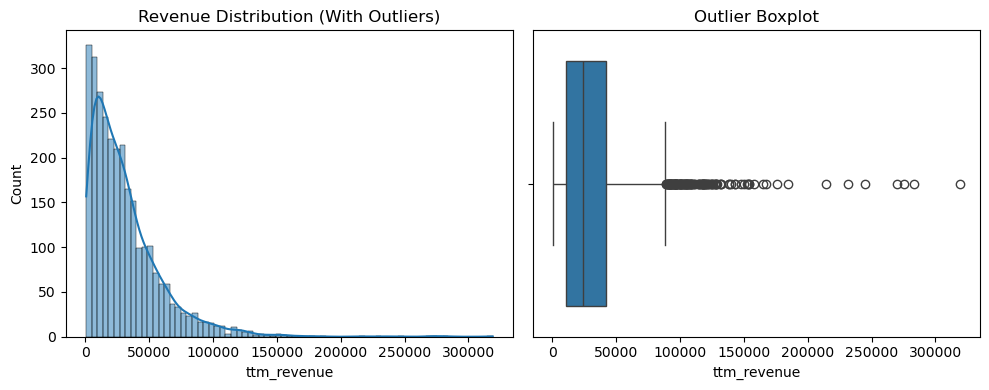

Lower bound: -36140.125, Upper bound: 88620.875
Removing rows outside this range. Total outliers: 127


In [3]:
# 1. Visualize the distribution and outliers
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
sns.histplot(df_listings["ttm_revenue"], kde=True)
plt.title("Revenue Distribution (With Outliers)")

plt.subplot(1, 2, 2)
sns.boxplot(x=df_listings["ttm_revenue"])
plt.title("Outlier Boxplot")
plt.tight_layout()
plt.show()

# 2. Calculate IQR thresholds
Q1 = df_listings["ttm_revenue"].quantile(0.25)
Q3 = df_listings["ttm_revenue"].quantile(0.75)
IQR = Q3 - Q1

# Define cutoffs (1.5 is standard, use 3.0 to target only extreme outliers)
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print(f"Lower bound: {lower_bound}, Upper bound: {upper_bound}")
print(
    f"Removing rows outside this range. Total outliers: "
    f"{((df_listings['ttm_revenue'] < lower_bound) | (df_listings['ttm_revenue'] > upper_bound)).sum()}"
)

# # 3. Filter the dataframe to remove the outliers
# df_clean = df_listings[
#     (df_listings["ttm_revenue"] >= lower_bound)
#     & (df_listings["ttm_revenue"] <= upper_bound)
# ]

In [5]:
# Isolate the extreme upper-bound outliers
upper_outliers = df_listings[df_listings["ttm_revenue"] > upper_bound]

# Sort them from highest to lowest and look at the top 10
top_outliers = upper_outliers.sort_values(by="ttm_revenue", ascending=False)

# Display the top 10 rows with selected columns (add your actual column names here)
print(f"Total upper outliers detected: {len(upper_outliers)}")
top_outliers[["gross_yield", "ttm_revenue", "property_val", "ttm_avg_rate", "city", "listing_name", "listing_type", "room_type", "rating_overall"]].head(50)  # Add columns like 'name' or 'id' to see context

Total upper outliers detected: 127


,gross_yield,ttm_revenue,property_val,ttm_avg_rate,city,listing_name,listing_type,room_type,rating_overall
305,NaN,318992.0,NaN,2762.1,pigeon forge,9 Bedroom•Indoor Pool• Chapel•Hot Tub•Arcade•G...,Entire cabin,entire_home,5.00
785,NaN,282841.0,NaN,1182.5,myrtle beach,Private Pool + Hot Tub | Beachfront | The Palms,Entire home,entire_home,4.83
2586,NaN,275363.0,NaN,967.7,gatlinburg,Big Luxury Gatlinburg Cabin | Hot Tub | Fire Pit,Entire cabin,entire_home,5.00
773,NaN,270067.0,NaN,1307.6,myrtle beach,Oceanfront Home -Private Pool-Low Tide Too,Entire home,entire_home,4.74
2585,0.225160,245090.0,1.088515e+06,742.7,gatlinburg,Luxury Cabin • Master Suites • Swimspa • Gameroom,Entire cabin,entire_home,4.94
2264,NaN,231242.0,NaN,1909.1,carolina beach,"""The Snow's Cut Chateau"" Make every day a Holi...",Entire home,entire_home,4.95
2763,NaN,214632.0,NaN,1007.3,gatlinburg,"Tons of games, hot tub, newly renovated, sleep...",Entire chalet,entire_home,4.74
514,NaN,184634.0,NaN,1140.7,pigeon forge,"Luxury Lodge - Private Pool, Views, Games + More!",Entire cabin,entire_home,4.00
1468,NaN,175733.0,NaN,688.6,durham,Luxury Home Downtown,Entire home,entire_home,4.89
2331,NaN,167169.0,NaN,703.6,charlotte,Downtown Bungalow 7 bedroom 4 bath,Entire bungalow,entire_home,4.90
